# Autoencoders: Compression, Reconstruction, and Denoising

**Student Name:** Saad Abdullah  
**Student ID:** 24132192  
**Course:** ML & NN 

**GitHub Repository:**  
https://github.com/[your-username]/autoencoder-tutorial

This notebook demonstrates how autoencoders learn compressed representations of data and reconstruct inputs. We explore how latent space size affects performance and extend the model to denoising tasks.

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

## Dataset

We use the MNIST dataset of handwritten digits. Each image is 28×28 pixels and is flattened into a vector of size 784 before being passed into the neural network.

In [3]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

## Autoencoder Architecture

An autoencoder consists of two main components:

- **Encoder**: compresses the input into a lower-dimensional representation  
- **Decoder**: reconstructs the original input from this compressed representation  

### Encoder

$$
z = f(x)
$$

The encoder maps the input data $x$ into a latent representation $z$, capturing the most important features.

### Decoder

$$
\hat{x} = g(z)
$$

The decoder reconstructs the original input from the latent representation.

### Full Model

$$
\hat{x} = g(f(x))
$$

The full autoencoder combines both steps, learning to approximate the original input through compression and reconstruction.

## Reconstruction Loss

The model is trained by minimising:

$$
L = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
$$

This encourages accurate reconstruction of the input.

In [4]:
def build_autoencoder(latent_dim):
    input_layer = Input(shape=(784,))
    
    #Encoder
    encoded = Dense(128, activation='relu')(input_layer)
    encoded = Dense(latent_dim, activation='relu')(encoded)
    
    #Decoder
    decoded = Dense(128, activation='relu')(encoded)
    decoded = Dense(784, activation='sigmoid')(decoded)
    
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)
    
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder

## Training Autoencoders

We compare two models:

- Latent dimension = 2 (high compression)  
- Latent dimension = 32 (lower compression)

In [5]:
# Small latent space
autoencoder_small, encoder_small = build_autoencoder(2)

history_small = autoencoder_small.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Larger latent space
autoencoder_large, encoder_large = build_autoencoder(32)

history_large = autoencoder_large.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)



Epoch 1/10

235/235 [==============================] - 6s 18ms/step - loss: 0.0863 - val_loss: 0.0677
Epoch 2/10
235/235 [==============================] - 2s 10ms/step - loss: 0.0661 - val_loss: 0.0651
Epoch 3/10
235/235 [==============================] - 3s 12ms/step - loss: 0.0641 - val_loss: 0.0634
Epoch 4/10
235/235 [==============================] - 2s 10ms/step - loss: 0.0600 - val_loss: 0.0559
Epoch 5/10
235/235 [==============================] - 5s 22ms/step - loss: 0.0547 - val_loss: 0.0538
Epoch 6/10
235/235 [==============================] - 5s 19ms/step - loss: 0.0532 - val_loss: 0.0525
Epoch 7/10
235/235 [==============================] - 4s 17ms/step - loss: 0.0516 - val_loss: 0.0509
Epoch 8/10
235/235 [==============================] - 2s 10ms/step - loss: 0.0501 - val_loss: 0.0499
Epoch 9/10
235/235 [==============================] - 2s 10ms/step - loss: 0.0492 - val_loss: 0.0490
Epoch 10/10
235/235 [==============================] - 2s 10ms/step - loss: 0.0485 - val

## Training and Validation Loss

This plot shows how the models learn over time.

Lower loss indicates better reconstruction. A small gap between training and validation loss suggests good generalisation.

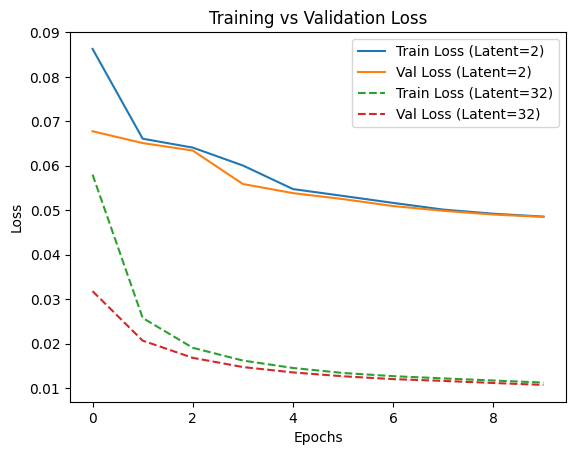

In [6]:
plt.figure()
plt.plot(history_small.history['loss'], label='Train Loss (Latent=2)')
plt.plot(history_small.history['val_loss'], label='Val Loss (Latent=2)')

plt.plot(history_large.history['loss'], linestyle='--', label='Train Loss (Latent=32)')
plt.plot(history_large.history['val_loss'], linestyle='--', label='Val Loss (Latent=32)')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Reconstruction Comparison

We compare original images with reconstructed outputs.

- Latent = 2 → blurry images  
- Latent = 32 → clearer images  

This shows the trade-off between compression and quality.

In [7]:
def plot_reconstruction_comparison(model_small, model_large, data, n=10):
    decoded_small = model_small.predict(data[:n])
    decoded_large = model_large.predict(data[:n])

    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Original
        plt.subplot(3, n, i + 1)
        plt.imshow(data[i].reshape(28, 28))
        plt.title("Original")
        plt.axis("off")

        # Small latent
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_small[i].reshape(28, 28))
        plt.title("Latent=2")
        plt.axis("off")

        # Large latent
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(decoded_large[i].reshape(28, 28))
        plt.title("Latent=32")
        plt.axis("off")

    plt.suptitle("Reconstruction Comparison")
    plt.show()

1/1 [==============================] - 0s 87ms/step


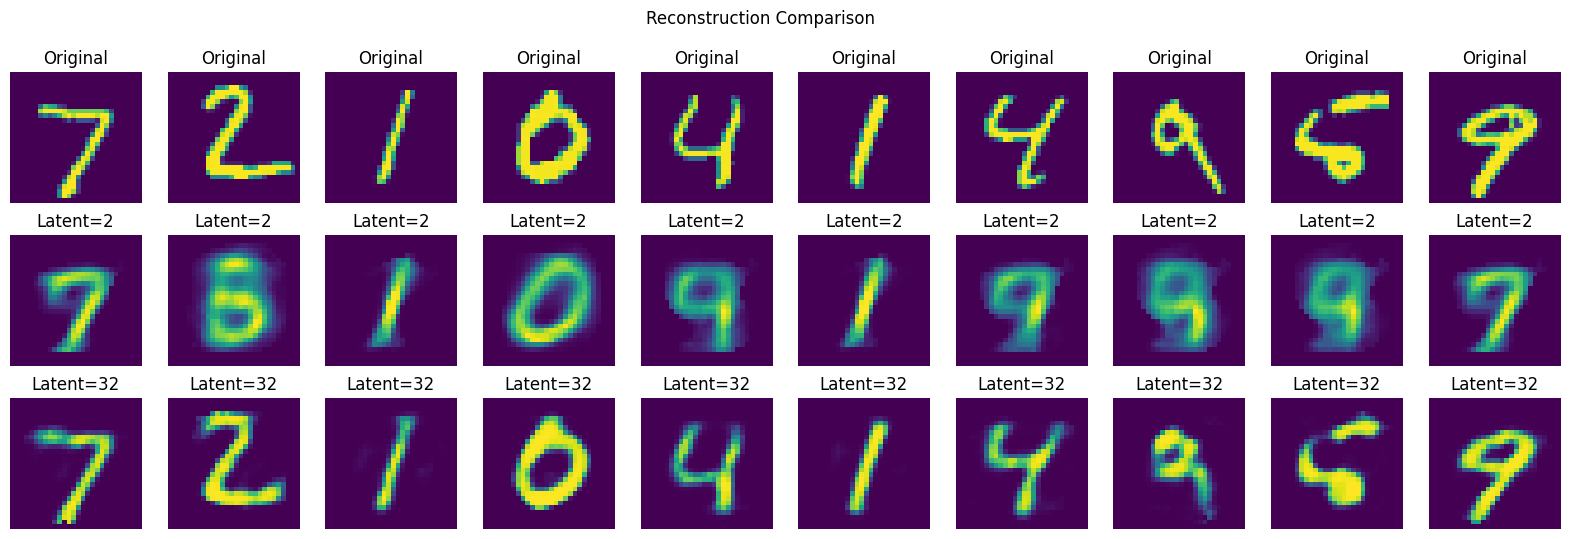

In [8]:
plot_reconstruction_comparison(autoencoder_small, autoencoder_large, x_test)

## Denoising Autoencoder

We add noise to the inputs and train the model to recover clean images.

This improves robustness and prevents simple memorisation.

In [9]:
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Train Denoising Autoencoder

In [ ]:
autoencoder_denoise, _ = build_autoencoder(32)

history_denoise = autoencoder_denoise.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
235/235 [==============================] - 3s 9ms/step - loss: 0.0579 - val_loss: 0.0324
Epoch 2/10
235/235 [==============================] - 4s 16ms/step - loss: 0.0279 - val_loss: 0.0238
Epoch 3/10
235/235 [==============================] - 2s 9ms/step - loss: 0.0221 - val_loss: 0.0198
Epoch 4/10
 10/235 [>.............................] - ETA: 1s - loss: 0.0201

Denoising Loss Curve

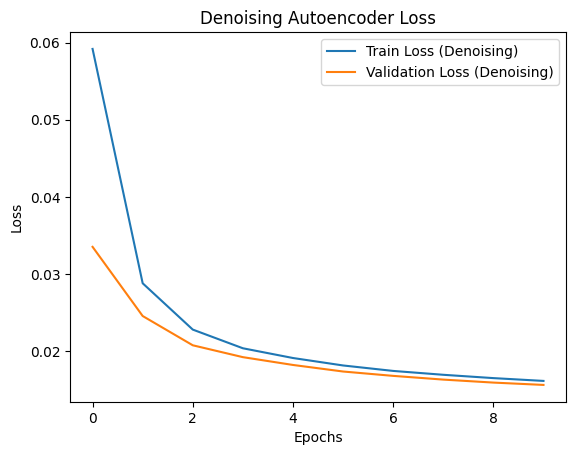

In [ ]:
plt.figure()
plt.plot(history_denoise.history['loss'], label='Train Loss (Denoising)')
plt.plot(history_denoise.history['val_loss'], label='Validation Loss (Denoising)')

plt.title("Denoising Autoencoder Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Denoising Results

The model reconstructs clean images from noisy inputs, showing it has learned robust features.

In [ ]:
def plot_denoising_results(model, noisy_data, clean_data, n=10):
    decoded = model.predict(noisy_data[:n])

    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_data[i].reshape(28, 28))
        plt.title("Noisy")
        plt.axis("off")

        # Reconstructed
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded[i].reshape(28, 28))
        plt.title("Reconstructed")
        plt.axis("off")

        # Original
        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_data[i].reshape(28, 28))
        plt.title("Original")
        plt.axis("off")

    plt.suptitle("Denoising Autoencoder Results")
    plt.show()

1/1 [==============================] - 0s 102ms/step


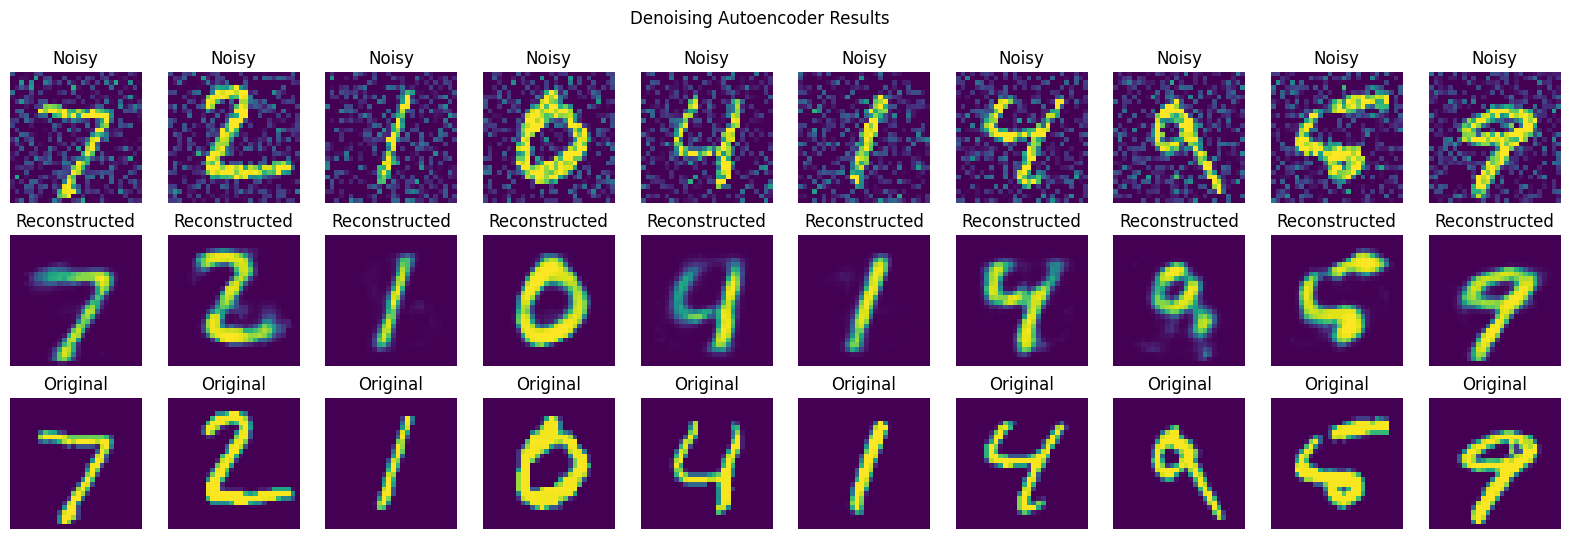

In [ ]:
plot_denoising_results(autoencoder_denoise, x_test_noisy, x_test)

## Latent Space Visualisation

We visualise compressed data in 2D. Clusters indicate learned structure.

313/313 [==============================] - 1s 3ms/step


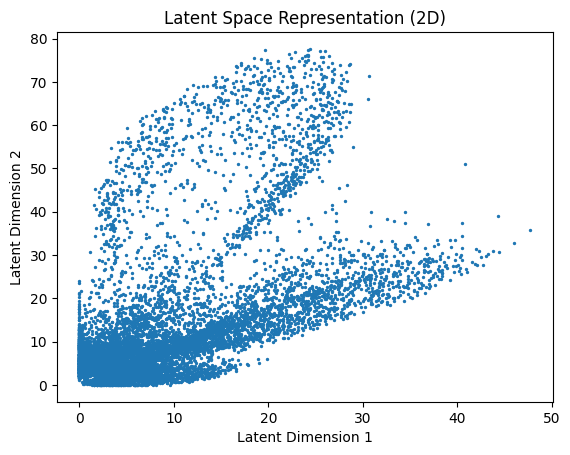

In [ ]:
encoded_data = encoder_small.predict(x_test)

plt.figure()
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], s=2)

plt.title("Latent Space Representation (2D)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.show()


This notebook demonstrated how autoencoders can:

- Learn compressed representations of high-dimensional data  
- Reconstruct inputs with varying levels of accuracy  
- Remove noise through denoising techniques  

The results highlight the importance of choosing an appropriate latent dimension and show how autoencoders can capture meaningful patterns in data.

Autoencoders are widely used in applications such as dimensionality reduction, anomaly detection, and image processing.

## References

Hinton, G. E. and Salakhutdinov, R. R. (2006)  
*Reducing the dimensionality of data with neural networks*. Science, 313(5786), pp. 504–507.

Chollet, F. (2017)  
*Deep Learning with Python*. Manning Publications.

Goodfellow, I., Bengio, Y. and Courville, A. (2016)  
*Deep Learning*. MIT Press. Available at: https://www.deeplearningbook.org/

TensorFlow (2024)  
*Keras Documentation*. Available at: https://keras.io/

LeCun, Y., Cortes, C. and Burges, C. J. C.  
*MNIST Handwritten Digit Database*. Available at: http://yann.lecun.com/exdb/mnist/